In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TRAIN_DATASET_DIR = "./learn_dataset_single_object"  # 学習: 単一物体
TEST_DATASET_DIR  = "./learn_dataset_fixed_angle"     # テスト: 2物体同時
TRAIN_META_CSV = os.path.join(TRAIN_DATASET_DIR, "metadata.csv")
TEST_META_CSV  = os.path.join(TEST_DATASET_DIR,  "metadata.csv")
MODEL_PATH = "./best_detector_agnostic.pt"

N_FIXED      = 10
FIXED_ANGLES = np.linspace(-5, 5, N_FIXED)  # 角度グリッド [度]
SIGMA_ANGLE  = 0.3                           # 角度方向Gaussianの標準偏差 [度]

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS     = 15
LR         = 1e-3

D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
print("TRAIN_META_CSV exists:", os.path.exists(TRAIN_META_CSV))
print("TEST_META_CSV  exists:", os.path.exists(TEST_META_CSV))

DEVICE: cpu
TRAIN_META_CSV exists: True
TEST_META_CSV  exists: True


In [3]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [4]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [ ]:
class MultiTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        npz_path = row["file"]
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join(".", npz_path))

        data = np.load(npz_path)
        x = load_all_rd_maps(npz_path)
        H, W = x.shape[1], x.shape[2]

        fixed_angles = data["fixed_angles"] if "fixed_angles" in data else FIXED_ANGLES

        valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
        valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0

        cy_angle = float(data["cyclist_true_angle_deg"]) if (valid_cy and "cyclist_true_angle_deg" in data) else 0.0
        ve_angle = float(data["vehicle_true_angle_deg"]) if (valid_ve and "vehicle_true_angle_deg" in data) else 0.0

        cy_heatmap = make_gaussian_heatmap(H, W, int(row["cyclist_true_d_idx"]), int(row["cyclist_true_r_idx"])) if valid_cy else np.zeros((H, W), dtype=np.float32)
        ve_heatmap = make_gaussian_heatmap(H, W, int(row["vehicle_true_d_idx"]), int(row["vehicle_true_r_idx"])) if valid_ve else np.zeros((H, W), dtype=np.float32)

        # 各角度チャンネルに対して、真の角度との距離でGaussian重みをかけたヒートマップを生成
        y = np.zeros((N_FIXED, H, W), dtype=np.float32)
        for i, angle in enumerate(fixed_angles):
            w_cy = float(np.exp(-0.5 * ((angle - cy_angle) / SIGMA_ANGLE) ** 2)) if valid_cy else 0.0
            w_ve = float(np.exp(-0.5 * ((angle - ve_angle) / SIGMA_ANGLE) ** 2)) if valid_ve else 0.0
            y[i] = np.clip(w_cy * cy_heatmap + w_ve * ve_heatmap, 0.0, 1.0)

        return {
            "x": torch.from_numpy(x).float(),
            "y": torch.from_numpy(y).float(),
            "cy_true_d": torch.tensor(int(row["cyclist_true_d_idx"]), dtype=torch.long),
            "cy_true_r": torch.tensor(int(row["cyclist_true_r_idx"]), dtype=torch.long),
            "ve_true_d": torch.tensor(int(row["vehicle_true_d_idx"]), dtype=torch.long),
            "ve_true_r": torch.tensor(int(row["vehicle_true_r_idx"]), dtype=torch.long),
            "valid_cy": torch.tensor(valid_cy, dtype=torch.long),
            "valid_ve": torch.tensor(valid_ve, dtype=torch.long),
        }

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=N_FIXED, out_channels=2, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(4)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        self.head = nn.Conv2d(fixed_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.head(x)  # logits (B, 2, H, W)

In [7]:
# 学習用: 単一物体(280train+60val) + 2物体(200train) / テスト: 2物体(100test)
RANDOM_SEED = 42

# --- 単一物体データ ---
single_df = pd.read_csv(TRAIN_META_CSV)
single_df = single_df[single_df["valid_all"] == 1].reset_index(drop=True)
single_df = single_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
single_train_df = single_df.iloc[:280].reset_index(drop=True)
single_val_df   = single_df.iloc[280:340].reset_index(drop=True)

# --- 2物体データ ---
two_df = pd.read_csv(TEST_META_CSV)
two_df = two_df[two_df["valid_all"] == 1].reset_index(drop=True)
two_df = two_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
two_train_df = two_df.iloc[:200].reset_index(drop=True)
test_df      = two_df.iloc[200:].reset_index(drop=True)

# --- 結合 ---
train_df = pd.concat([single_train_df, two_train_df], ignore_index=True)
val_df   = single_val_df  # val は単一物体から

print(f"train: {len(train_df)}  (単一:{len(single_train_df)}, 2物体:{len(two_train_df)})")
print(f"val:   {len(val_df)}")
print(f"test:  {len(test_df)}")
display(train_df.head())


train: 480  (単一:280, 2物体:200)
val:   60
test:  100


,file,scenario,cyclist_true_d_idx,cyclist_true_r_idx,vehicle_true_d_idx,vehicle_true_r_idx,valid_cyclist,valid_vehicle,valid_all,source_index,sample_id,source_index_cyclist,source_index_vehicle,cyclist_true_range,cyclist_true_velocity,cyclist_true_angle_deg,vehicle_true_range,vehicle_true_velocity,vehicle_true_angle_deg
0,./learn_dataset_single_object\sample_00110.npz,cyclist_only,1,140,0,0,True,0,1,111.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,./learn_dataset_single_object\sample_00419.npz,vehicle_only,0,0,1,126,0,True,1,157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,./learn_dataset_single_object\sample_00565.npz,vehicle_only,0,0,1,112,0,True,1,213.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,./learn_dataset_single_object\sample_00077.npz,cyclist_only,1,149,0,0,True,0,1,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,./learn_dataset_single_object\sample_00181.npz,cyclist_only,1,122,0,0,True,0,1,182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [ ]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=3.0, sigma_r=1.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def load_all_rd_maps(npz_path):
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]
    result = []
    for i in range(rd_maps.shape[0]):
        rd_mag = np.abs(rd_maps[i]).astype(np.float32)
        rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
        result.append(rd_db)
    return np.stack(result, axis=0)

def decode_peaks_from_logits(logits, threshold=0.8):
    """(N_FIXED, H, W) ヒートマップから3D NMSでピーク検出 [(ch,d,r,conf),...]"""
    prob = torch.sigmoid(logits)[0]  # (N_FIXED, H, W)
    C, H, W = prob.shape
    p = prob.clone()
    results = []
    while True:
        flat_idx = torch.argmax(p).item()
        ch_idx = flat_idx // (H * W)
        rem    = flat_idx % (H * W)
        d_idx  = rem // W
        r_idx  = rem % W
        conf = float(prob[ch_idx, d_idx, r_idx].item())
        if conf < threshold:
            break
        results.append((ch_idx, d_idx, r_idx, conf))
        ch0, ch1 = max(0, ch_idx - 1), min(C, ch_idx + 2)
        d0,  d1  = max(0, d_idx  - 3), min(H, d_idx  + 4)
        r0,  r1  = max(0, r_idx  - 1), min(W, r_idx  + 2)
        p[ch0:ch1, d0:d1, r0:r1] = 0.0
    return results

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)

In [10]:
def bce_loss_from_logits(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)

def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    return (1 - num / den).mean()

def compute_loss(logits, targets):
    return bce_loss_from_logits(logits, targets) + dice_loss_from_logits(logits, targets)

def match_peaks_to_targets(peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r):
    # peaks: [(ch, d, r, conf), ...]  → (d,r) は index 1,2
    import itertools
    if len(peaks) == 0:
        return (-1, -1), (-1, -1)
    if len(peaks) == 1:
        p = peaks[0][1:3]  # (d, r)
        cy_dist = (p[0]-cy_true_d)**2 + (p[1]-cy_true_r)**2
        ve_dist = (p[0]-ve_true_d)**2 + (p[1]-ve_true_r)**2
        if cy_dist <= ve_dist:
            return p, (-1, -1)
        else:
            return (-1, -1), p
    best_cy, best_ve = peaks[0][1:3], peaks[1][1:3]
    best_cost = float('inf')
    for p1, p2 in itertools.permutations(peaks[:2]):
        cost = ((p1[1]-cy_true_d)**2 + (p1[2]-cy_true_r)**2 +
                (p2[1]-ve_true_d)**2 + (p2[2]-ve_true_r)**2)
        if cost < best_cost:
            best_cost = cost
            best_cy, best_ve = p1[1:3], p2[1:3]
    return best_cy, best_ve

def run_epoch(model, loader, optimizer=None, device='cpu'):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    cy_hits, cy_total = 0, 0
    ve_hits, ve_total = 0, 0

    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        cy_true_d = batch['cy_true_d'].cpu().numpy()
        cy_true_r = batch['cy_true_r'].cpu().numpy()
        ve_true_d = batch['ve_true_d'].cpu().numpy()
        ve_true_r = batch['ve_true_r'].cpu().numpy()
        valid_cy  = batch['valid_cy'].cpu().numpy()
        valid_ve  = batch['valid_ve'].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        logits = model(x)
        loss = compute_loss(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            peaks = decode_peaks_from_logits(logits[i:i+1].detach().cpu())
            (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
                peaks, int(cy_true_d[i]), int(cy_true_r[i]),
                int(ve_true_d[i]), int(ve_true_r[i])
            )
            if valid_cy[i]:
                cy_hits  += int(compute_hit(cy_d, cy_r, int(cy_true_d[i]), int(cy_true_r[i])))
                cy_total += 1
            if valid_ve[i]:
                ve_hits  += int(compute_hit(ve_d, ve_r, int(ve_true_d[i]), int(ve_true_r[i])))
                ve_total += 1

    n = len(loader.dataset)
    mean_loss   = total_loss / max(n, 1)
    cy_hit_rate = cy_hits / max(cy_total, 1)
    ve_hit_rate = ve_hits / max(ve_total, 1)
    return mean_loss, cy_hit_rate, ve_hit_rate

In [31]:
train_ds = MultiTargetDataset(train_df)
val_ds   = MultiTargetDataset(val_df)
test_ds  = MultiTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = RadarLightUNet(in_channels=N_FIXED, out_channels=N_FIXED).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_cy_hit, train_ve_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss,   val_cy_hit,   val_ve_hit   = run_epoch(model, val_loader,   optimizer=None,      device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_cy_hit": train_cy_hit,
        "train_ve_hit": train_ve_hit,
        "val_loss": val_loss,
        "val_cy_hit": val_cy_hit,
        "val_ve_hit": val_ve_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} cy={train_cy_hit:.3f} ve={train_ve_hit:.3f} | "
        f"val_loss={val_loss:.4f}   cy={val_cy_hit:.3f} ve={val_ve_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

epoch=01 train_loss=1.0555 cy=0.000 ve=0.000 | val_loss=1.0032   cy=0.000 ve=0.000
epoch=02 train_loss=1.0121 cy=0.000 ve=0.000 | val_loss=1.0015   cy=0.000 ve=0.000
epoch=03 train_loss=1.0031 cy=0.000 ve=0.000 | val_loss=0.9990   cy=0.000 ve=0.000
epoch=04 train_loss=0.9918 cy=0.191 ve=0.000 | val_loss=0.9861   cy=0.423 ve=0.000
epoch=05 train_loss=0.9728 cy=0.789 ve=0.138 | val_loss=0.9700   cy=0.885 ve=0.735
epoch=06 train_loss=0.9611 cy=0.688 ve=0.455 | val_loss=0.9615   cy=0.115 ve=0.824
epoch=07 train_loss=0.9472 cy=0.642 ve=0.746 | val_loss=0.9503   cy=0.769 ve=1.000
epoch=08 train_loss=0.9369 cy=0.879 ve=0.862 | val_loss=0.9462   cy=1.000 ve=1.000
epoch=09 train_loss=0.9302 cy=0.945 ve=0.955 | val_loss=0.9449   cy=1.000 ve=1.000
epoch=10 train_loss=0.9272 cy=0.960 ve=0.940 | val_loss=0.9444   cy=1.000 ve=1.000
epoch=11 train_loss=0.9268 cy=0.965 ve=0.961 | val_loss=0.9439   cy=1.000 ve=1.000
epoch=12 train_loss=0.9253 cy=0.960 ve=0.976 | val_loss=0.9438   cy=1.000 ve=1.000
epoc

,epoch,train_loss,train_cy_hit,train_ve_hit,val_loss,val_cy_hit,val_ve_hit
10,11,0.926847,0.965318,0.961078,0.943934,1.0,1.0
11,12,0.925279,0.959538,0.976048,0.943820,1.0,1.0
12,13,0.925022,0.962428,0.961078,0.943683,1.0,1.0
13,14,0.924282,0.979769,0.973054,0.944091,1.0,1.0
14,15,0.924611,0.979769,0.979042,0.943630,1.0,1.0


In [12]:
best_model = RadarLightUNet(in_channels=N_FIXED, out_channels=N_FIXED).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_cy_hit, test_ve_hit = run_epoch(best_model, test_loader, optimizer=None, device=DEVICE)
print(f"test_loss={test_loss:.4f}  cyclist_hit={test_cy_hit:.3f}  vehicle_hit={test_ve_hit:.3f}")

test_loss=0.7842  cyclist_hit=0.800  vehicle_hit=0.880


=== sample 0 ===
[detection 1] angle=0.6° d=2, r=124, conf=1.000
[detection 2] angle=2.8° d=1, r=124, conf=1.000
[detection 3] angle=3.9° d=2, r=167, conf=1.000
[detection 4] angle=1.7° d=1, r=167, conf=1.000
[detection 5] angle=-1.7° d=0, r=124, conf=0.905
[true] cyclist=(1,167,2.8472322230068934)  vehicle=(1,124,1.688926948432679)


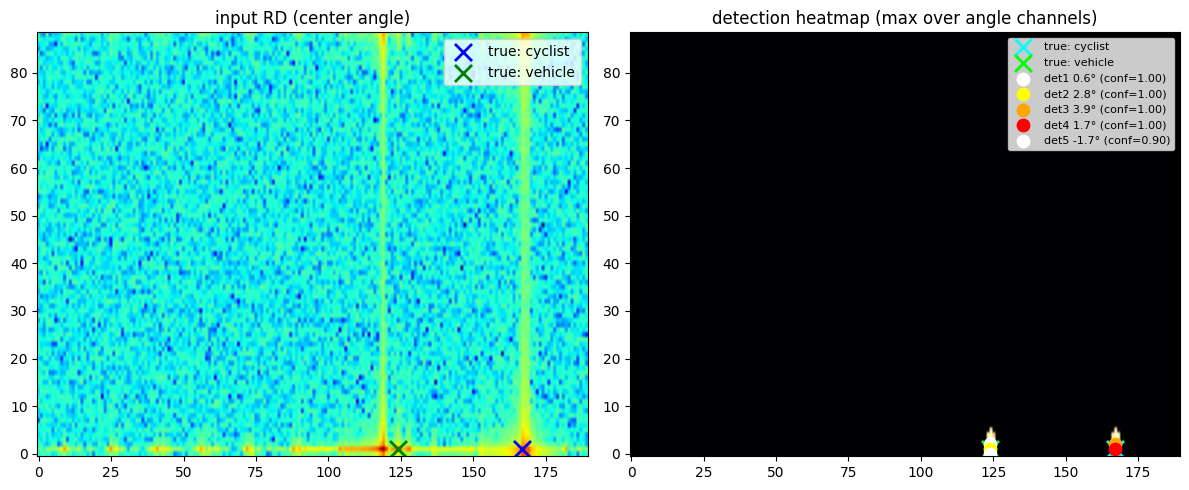

=== sample 1 ===
[detection 1] angle=1.7° d=2, r=144, conf=1.000
[detection 2] angle=3.9° d=3, r=137, conf=1.000
[detection 3] angle=-0.6° d=1, r=144, conf=0.997
[detection 4] angle=1.7° d=2, r=138, conf=0.996
[detection 5] angle=3.9° d=0, r=144, conf=0.902
[true] cyclist=(1,137,3.111753449744785)  vehicle=(1,144,1.5469580893186743)


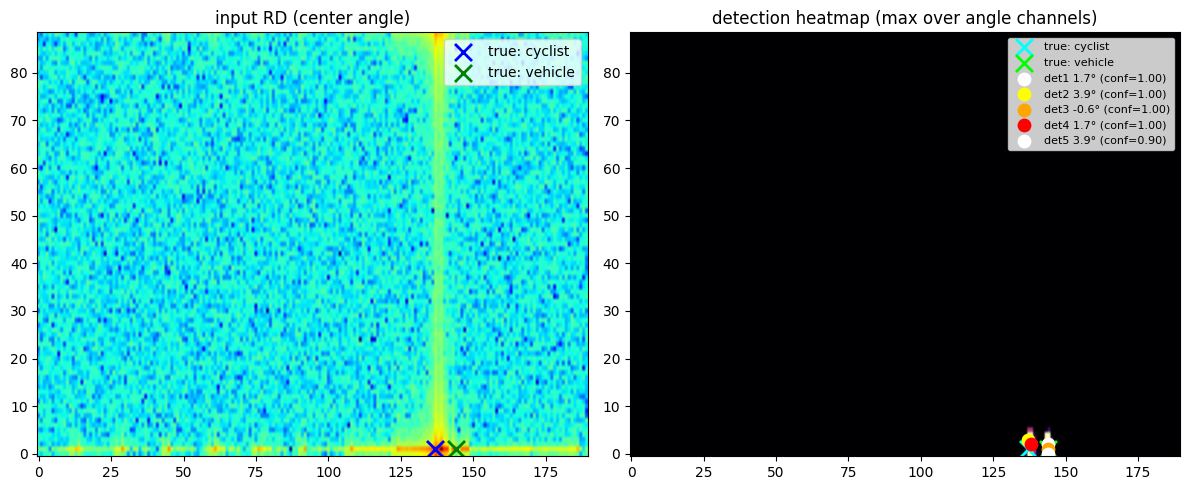

In [21]:
def show_prediction(sample_idx=0):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    peaks = decode_peaks_from_logits(logits.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    cy_true_a = float(row["cyclist_true_angle_deg"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])
    ve_true_a = float(row["vehicle_true_angle_deg"])

    print(f"=== sample {sample_idx} ===")
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        print(f"[detection {j+1}] angle={FIXED_ANGLES[pk_ch]:.1f}° d={pk_d}, r={pk_r}, conf={pk_c:.3f}")
    print(f"[true] cyclist=({cy_true_d},{cy_true_r},{cy_true_a})  vehicle=({ve_true_d},{ve_true_r},{ve_true_a})")

    rd_db   = x[N_FIXED // 2]
    heatmap = torch.sigmoid(logits)[0].max(dim=0).values.cpu().numpy()
    colors  = ["white", "yellow", "orange", "red"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        axes[1].scatter([pk_r], [pk_d], c=colors[j % len(colors)], marker="o", s=80,
                        label=f"det{j+1} {FIXED_ANGLES[pk_ch]:.1f}° (conf={pk_c:.2f})")
    axes[1].set_title("detection heatmap (max over angle channels)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_prediction(sample_idx=0)
show_prediction(sample_idx=1)

In [22]:
def show_failure_pattern(sample_idx, title=""):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    prob = torch.sigmoid(logits)[0].max(dim=0).values.cpu().numpy()  # 全chの最大値

    cy_r = int(row['cyclist_true_r_idx'])
    ve_r = int(row['vehicle_true_r_idx'])
    cy_d = int(row['cyclist_true_d_idx'])
    ve_d = int(row['vehicle_true_d_idx'])
    rd_center = x[N_FIXED // 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}  [sample {sample_idx}]  |cy_r - ve_r| = {abs(cy_r - ve_r)} bins")

    axes[0].imshow(rd_center, aspect='auto', origin='lower', cmap='jet')
    axes[0].plot(cy_r, cy_d, 'bx', ms=10, mew=2, label='true: cyclist')
    axes[0].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    im = axes[1].imshow(prob, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
    axes[1].plot(cy_r, cy_d, 'cx', ms=10, mew=2, label='true: cyclist')
    axes[1].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[1].set_title("heatmap (max over angle channels, no threshold)")
    axes[1].legend()
    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()

In [23]:
def collect_predictions(meta_df):
    rows = []
    for i in range(len(meta_df)):
        row = meta_df.iloc[i]
        npz_path = row['file']
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join('.', npz_path))
        x = load_all_rd_maps(npz_path)
        x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
        with torch.no_grad():
            logits = best_model(x_tensor)
        peaks = decode_peaks_from_logits(logits.cpu())
        # peaks: [(ch, d, r, conf), ...]

        det1 = peaks[0] if len(peaks) > 0 else (-1, -1, -1, 0.0)
        det2 = peaks[1] if len(peaks) > 1 else (-1, -1, -1, 0.0)

        cy_true_d = int(row['cyclist_true_d_idx'])
        cy_true_r = int(row['cyclist_true_r_idx'])
        ve_true_d = int(row['vehicle_true_d_idx'])
        ve_true_r = int(row['vehicle_true_r_idx'])

        (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
            peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r
        )

        rows.append({
            'sample_idx': i,
            'file': row['file'],
            'det1_d': det1[1], 'det1_r': det1[2], 'det1_conf': det1[3],
            'det2_d': det2[1], 'det2_r': det2[2], 'det2_conf': det2[3],
            'cy_true_d': cy_true_d, 'cy_true_r': cy_true_r,
            've_true_d': ve_true_d, 've_true_r': ve_true_r,
            'cy_d_err': cy_d - cy_true_d, 'cy_r_err': cy_r - cy_true_r,
            've_d_err': ve_d - ve_true_d, 've_r_err': ve_r - ve_true_r,
            'cy_hit': compute_hit(cy_d, cy_r, cy_true_d, cy_true_r),
            've_hit': compute_hit(ve_d, ve_r, ve_true_d, ve_true_r),
        })
    return pd.DataFrame(rows)

In [24]:
pred_df = collect_predictions(test_df)

print("=== hit rate ===")
print(f"cyclist正解への検出率: {pred_df['cy_hit'].mean():.3f}")
print(f"vehicle正解への検出率: {pred_df['ve_hit'].mean():.3f}")

print("=== cyclist 失敗例 ===")
display(pred_df[pred_df["cy_hit"] == False][["cy_true_d","cy_true_r","det1_d","det1_r","det2_d","det2_r"]].head())
print("=== vehicle 失敗例 ===")
display(pred_df[pred_df["ve_hit"] == False][["ve_true_d","ve_true_r","det1_d","det1_r","det2_d","det2_r"]].head())


=== hit rate ===
cyclist正解への検出率: 0.800
vehicle正解への検出率: 0.880
=== cyclist 失敗例 ===


,cy_true_d,cy_true_r,det1_d,det1_r,det2_d,det2_r
0,1,167,2,124,1,124
8,1,152,0,122,4,122
17,1,97,2,158,1,158
24,1,162,2,96,1,96
31,1,107,2,134,1,134


=== vehicle 失敗例 ===


,ve_true_d,ve_true_r,det1_d,det1_r,det2_d,det2_r
8,1,122,0,122,4,122
19,1,166,2,158,1,160
35,1,90,2,165,1,165
39,1,143,0,142,4,142
45,1,142,1,136,2,137


r_diff (bins) ごとの失敗集計:
 r_diff   total   ve_fail   ve_fail%   cy_fail   cy_fail%
------------------------------------------------------------
      0       1         0       0.0%         0       0.0%
      1       1         0       0.0%         0       0.0%
      2       3         0       0.0%         0       0.0%
      3       2         0       0.0%         0       0.0%
      4       3         1      33.3%         0       0.0%
      5       2         0       0.0%         0       0.0%
      6       3         0       0.0%         0       0.0%
      7       3         0       0.0%         0       0.0%
      8       4         1      25.0%         2      50.0%
      9       3         0       0.0%         1      33.3%
     10       2         0       0.0%         0       0.0%
     11       3         1      33.3%         2      66.7%
     12       3         0       0.0%         0       0.0%
     13       4         0       0.0%         0       0.0%
     14       2         1      50.0%         0

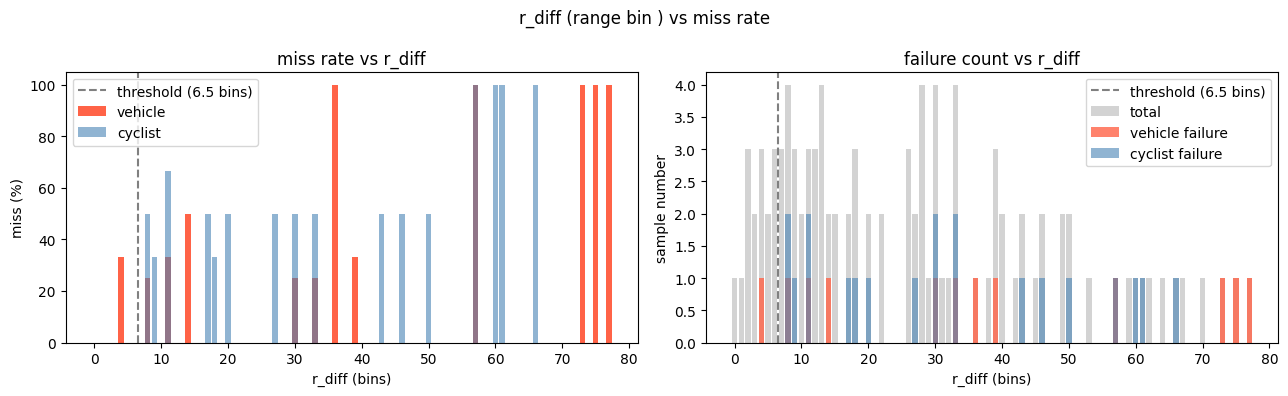

In [25]:
# === 近接失敗ケース: r_diff ごとの失敗数・失敗率 ===
import matplotlib.pyplot as plt
import numpy as np

# 全サンプルにr_diffを付加
pred_df2 = pred_df.copy()
pred_df2['r_diff'] = abs(pred_df2['cy_true_r'] - pred_df2['ve_true_r'])

# r_diff ごとに集計
summary = []
for d in sorted(pred_df2['r_diff'].unique()):
    sub = pred_df2[pred_df2['r_diff'] == d]
    total = len(sub)
    ve_fail = (sub['ve_hit'] == 0).sum()
    cy_fail = (sub['cy_hit'] == 0).sum()
    summary.append({'r_diff': d, 'total': total,
                     've_fail': ve_fail, 'cy_fail': cy_fail,
                     've_fail_rate': ve_fail / total,
                     'cy_fail_rate': cy_fail / total})

import pandas as pd
summary_df = pd.DataFrame(summary)

print('r_diff (bins) ごとの失敗集計:')
print(f'{"r_diff":>7}  {"total":>6}  {"ve_fail":>8}  {"ve_fail%":>9}  {"cy_fail":>8}  {"cy_fail%":>9}')
print('-' * 60)
for _, row in summary_df.iterrows():
    print(f"{int(row['r_diff']):>7}  {int(row['total']):>6}  {int(row['ve_fail']):>8}  {row['ve_fail_rate']*100:>8.1f}%  {int(row['cy_fail']):>8}  {row['cy_fail_rate']*100:>8.1f}%")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('r_diff (range bin ) vs miss rate')

diffs = summary_df['r_diff'].values
axes[0].bar(diffs, summary_df['ve_fail_rate'] * 100, color='tomato', label='vehicle')
axes[0].bar(diffs, summary_df['cy_fail_rate'] * 100, color='steelblue', alpha=0.6, label='cyclist')
axes[0].axvline(6.5, color='gray', linestyle='--', label='threshold (6.5 bins)')
axes[0].set_xlabel('r_diff (bins)')
axes[0].set_ylabel('miss (%)')
axes[0].set_title('miss rate vs r_diff')
axes[0].legend()

axes[1].bar(diffs, summary_df['total'], color='lightgray', label='total')
axes[1].bar(diffs, summary_df['ve_fail'], color='tomato', alpha=0.8, label='vehicle failure')
axes[1].bar(diffs, summary_df['cy_fail'], color='steelblue', alpha=0.6, label='cyclist failure')
axes[1].axvline(6.5, color='gray', linestyle='--', label='threshold (6.5 bins)')
axes[1].set_xlabel('r_diff (bins)')
axes[1].set_ylabel('sample number')
axes[1].set_title('failure count vs r_diff')
axes[1].legend()

plt.tight_layout()
plt.show()


 r_diff  total    n=0    n=1    n=2   cy_min_dr   ve_min_dr
------------------------------------------------------------
      0      1      0      0      1         0.0         0.0
      1      1      0      0      1         0.0         1.0
      2      3      0      0      3         1.0         1.0
      3      2      0      0      2         0.5         2.5
      4      3      0      0      3         0.0         0.0
      5      2      0      0      2         0.0         1.0
      6      3      0      0      3         0.0         1.0
      7      3      0      0      3         0.0         0.0
      8      4      0      0      4         2.0         0.5
      9      3      0      0      3         0.0         1.0
     10      2      0      0      2         0.0         0.5
     11      3      0      0      3         0.0         0.0
     12      3      0      0      3         0.0         0.0
     13      4      0      0      4         0.0         0.0
     14      2      0      0      2    

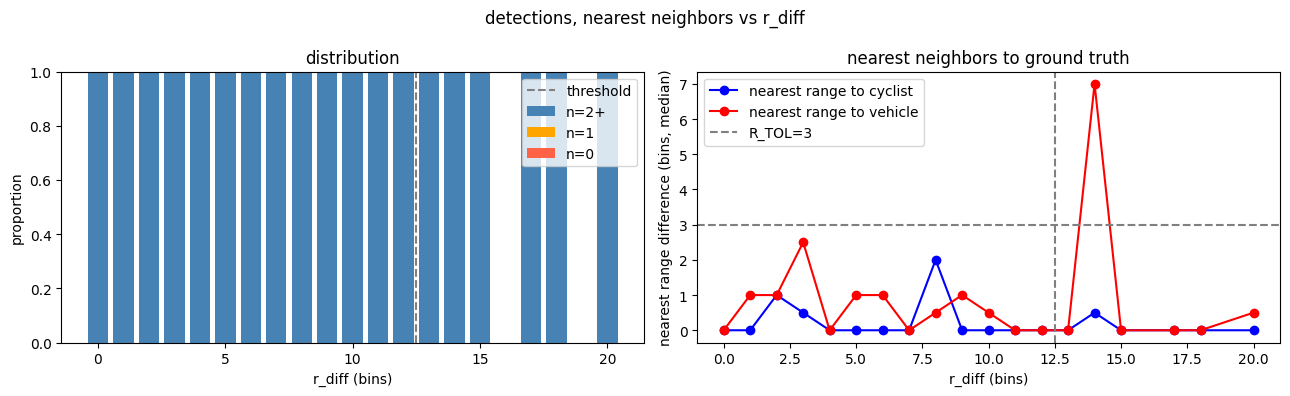

In [26]:
# === 検出数・最近傍距離ベースの分析 ===
import torch, numpy as np, matplotlib.pyplot as plt

pred_df['r_diff'] = abs(pred_df['cy_true_r'] - pred_df['ve_true_r'])

rows = []
for _, row in pred_df.iterrows():
    idx = int(row['sample_idx'])
    npz_path = test_df.iloc[idx]['file']
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join('.', npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())
    # peaks: [(ch, d, r, conf), ...]

    cy_r = int(row['cy_true_r']); cy_d = int(row['cy_true_d'])
    ve_r = int(row['ve_true_r']); ve_d = int(row['ve_true_d'])

    if len(peaks) > 0:
        cy_min_dr = min(abs(p[2] - cy_r) for p in peaks)
        ve_min_dr = min(abs(p[2] - ve_r) for p in peaks)
    else:
        cy_min_dr = ve_min_dr = 999

    rows.append({
        'r_diff': int(row['r_diff']),
        'n_peaks': len(peaks),
        'cy_min_dr': cy_min_dr,
        've_min_dr': ve_min_dr,
    })

det_df = pd.DataFrame(rows)

print(f"{'r_diff':>7}  {'total':>5}  {'n=0':>5}  {'n=1':>5}  {'n=2':>5}  {'cy_min_dr':>10}  {'ve_min_dr':>10}")
print("-" * 60)
for d in sorted(det_df['r_diff'].unique()):
    sub = det_df[det_df['r_diff'] == d]
    if d > 15:
        continue
    n0 = (sub['n_peaks'] == 0).sum()
    n1 = (sub['n_peaks'] == 1).sum()
    n2 = (sub['n_peaks'] >= 2).sum()
    cy_med = sub['cy_min_dr'].median()
    ve_med = sub['ve_min_dr'].median()
    print(f"{d:>7}  {len(sub):>5}  {n0:>5}  {n1:>5}  {n2:>5}  {cy_med:>10.1f}  {ve_med:>10.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('detections, nearest neighbors vs r_diff')

diffs = sorted(det_df['r_diff'].unique())
diffs_plot = [d for d in diffs if d <= 20]
n0_rate = [((det_df[det_df['r_diff']==d]['n_peaks']==0).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
n1_rate = [((det_df[det_df['r_diff']==d]['n_peaks']==1).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
n2_rate = [((det_df[det_df['r_diff']==d]['n_peaks']>=2).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
axes[0].bar(diffs_plot, n2_rate, label='n=2+', color='steelblue')
axes[0].bar(diffs_plot, n1_rate, bottom=n2_rate, label='n=1', color='orange')
axes[0].bar(diffs_plot, n0_rate, bottom=[a+b for a,b in zip(n2_rate,n1_rate)], label='n=0', color='tomato')
axes[0].axvline(12.5, color='gray', linestyle='--', label='threshold')
axes[0].set_xlabel('r_diff (bins)'); axes[0].set_ylabel('proportion')
axes[0].set_title('distribution'); axes[0].legend()

cy_meds = [det_df[det_df['r_diff']==d]['cy_min_dr'].median() for d in diffs_plot]
ve_meds = [det_df[det_df['r_diff']==d]['ve_min_dr'].median() for d in diffs_plot]
axes[1].plot(diffs_plot, cy_meds, 'b-o', label='nearest range to cyclist')
axes[1].plot(diffs_plot, ve_meds, 'r-o', label='nearest range to vehicle')
axes[1].axhline(3, color='gray', linestyle='--', label='R_TOL=3')
axes[1].axvline(12.5, color='gray', linestyle='--')
axes[1].set_xlabel('r_diff (bins)'); axes[1].set_ylabel('nearest range difference (bins, median)')
axes[1].set_title('nearest neighbors to ground truth'); axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# hitサンプルのみで誤差を計算
cy_hit_df = pred_df[pred_df['cy_hit'] == 1]
ve_hit_df = pred_df[pred_df['ve_hit'] == 1]

print("=== 誤差統計 (hit samples only) ===")
err_cols = pd.DataFrame({
    'cy_d_err': cy_hit_df['cy_d_err'],
    'cy_r_err': cy_hit_df['cy_r_err'],
    've_d_err': ve_hit_df['ve_d_err'],
    've_r_err': ve_hit_df['ve_r_err'],
})
print(err_cols.describe().loc[['mean','std','max','min']])


=== 誤差統計 (hit samples only) ===
      cy_d_err  cy_r_err  ve_d_err  ve_r_err
mean  1.012500  0.000000  0.284091 -0.113636
std   0.435563  0.355784  0.478236  0.575991
max   2.000000  1.000000  2.000000  3.000000
min   0.000000 -1.000000  0.000000 -2.000000


scenario: cyclist_only
det1: angle=3.9° d=2, r=168, conf=1.0000
det2: angle=1.7° d=1, r=168, conf=0.9999


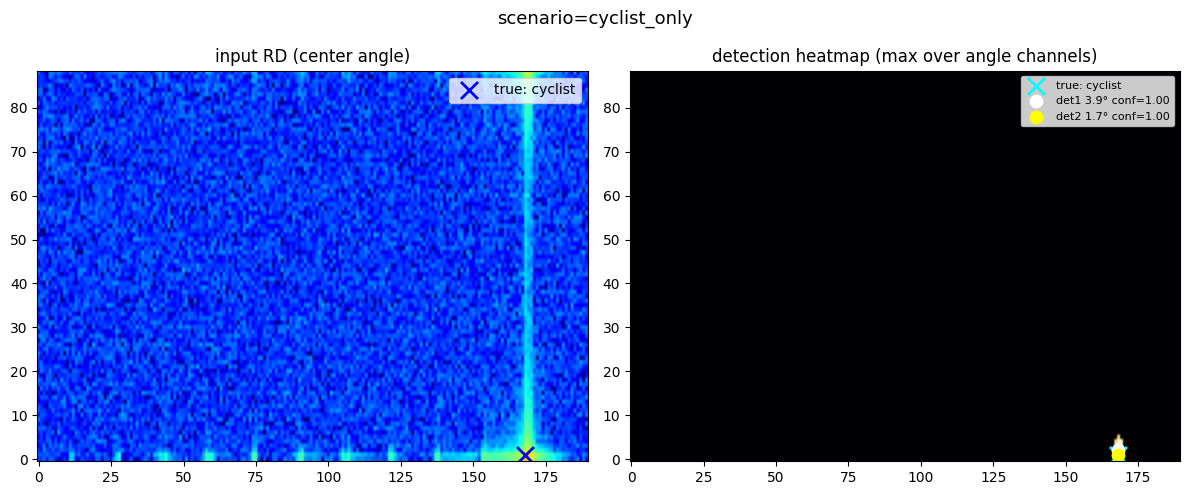

scenario: vehicle_only
det1: angle=1.7° d=1, r=99, conf=1.0000
det2: angle=-0.6° d=2, r=99, conf=0.9997
det3: angle=3.9° d=1, r=99, conf=0.9807


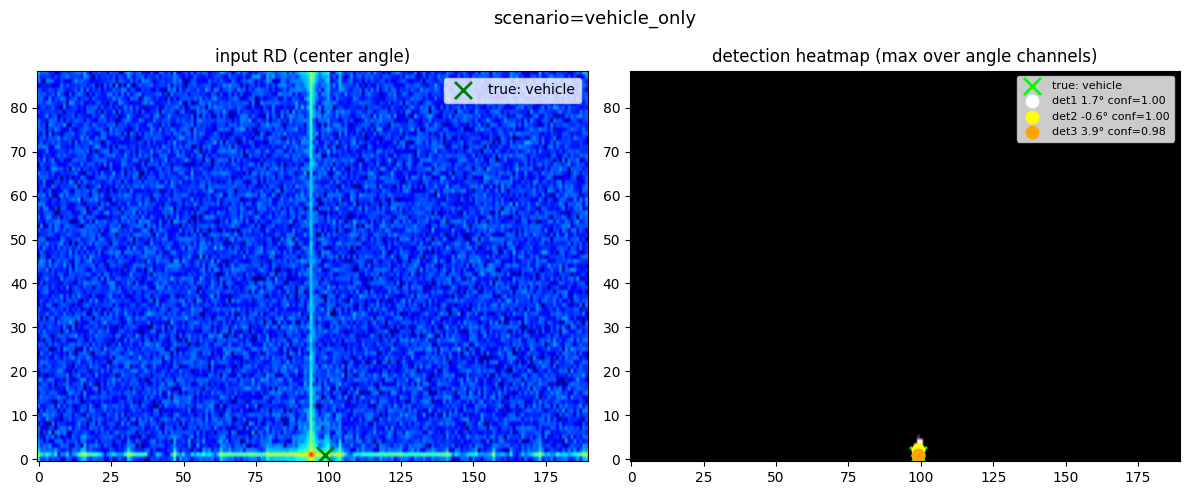

In [28]:
def show_channel_suppression(scenario, sample_idx=0):
    single_df = pd.read_csv("./learn_dataset_single_object/metadata.csv")
    single_df = single_df[single_df["scenario"] == scenario].reset_index(drop=True)
    row = single_df.iloc[sample_idx]

    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    heatmap = torch.sigmoid(logits)[0].max(dim=0).values.cpu().numpy()
    peaks = decode_peaks_from_logits(logits.cpu())

    valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
    valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0
    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"scenario: {scenario}")
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        print(f"det{j+1}: angle={FIXED_ANGLES[pk_ch]:.1f}° d={pk_d}, r={pk_r}, conf={pk_c:.4f}")

    rd_db = x[N_FIXED // 2]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"scenario={scenario}", fontsize=13)

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet", vmin=-90, vmax=0)
    if valid_cy:
        axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    if valid_cy:
        axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    colors = ["white", "yellow", "orange", "red"]
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        axes[1].scatter([pk_r], [pk_d], c=colors[j % len(colors)], marker="o", s=80,
                        label=f"det{j+1} {FIXED_ANGLES[pk_ch]:.1f}° conf={pk_c:.2f}")
    axes[1].set_title("detection heatmap (max over angle channels)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_channel_suppression("cyclist_only", sample_idx=0)
show_channel_suppression("vehicle_only", sample_idx=0)

シナリオテスト: 31 サンプル
 step   cy_idx   ve_idx  r_diff  n_peaks   cy_dr   ve_dr  confs
---------------------------------------------------------------------------
    0      150      100      11      n=4     0.0     0.0  [1.0, 1.0, 0.985, 0.968] *FP*
    1      153      105      11      n=6     0.0     0.0  [1.0, 1.0, 0.999, 0.997, 0.986, 0.925] *FP*
    2      156      110       9      n=4     0.0     4.0  [1.0, 0.985, 0.97, 0.918] *FP*
    3      159      115       9      n=6     0.0     0.0  [1.0, 1.0, 1.0, 1.0, 0.989, 0.944] *FP*
    4      162      120       9      n=6     0.0     0.0  [1.0, 1.0, 0.996, 0.971, 0.971, 0.951] *FP*
    5      165      125       9      n=4     0.0     0.0  [1.0, 0.995, 0.985, 0.979] *FP*
    6      168      130       7      n=5     0.0     1.0  [1.0, 1.0, 0.996, 0.953, 0.831] *FP*
    7      171      135       7      n=4     0.0     0.0  [1.0, 1.0, 0.993, 0.988] *FP*
    8      174      140       7      n=6     0.0     0.0  [1.0, 1.0, 1.0, 0.999, 0.999, 0.9

C:\Users\kousu\AppData\Local\Temp\ipykernel_25176\3919134218.py:82: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_25176\3919134218.py:82: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_25176\3919134218.py:82: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_25176\3919134218.py:82: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_25176\3919134218.py:82: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_25176\3919134218.py:82: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from

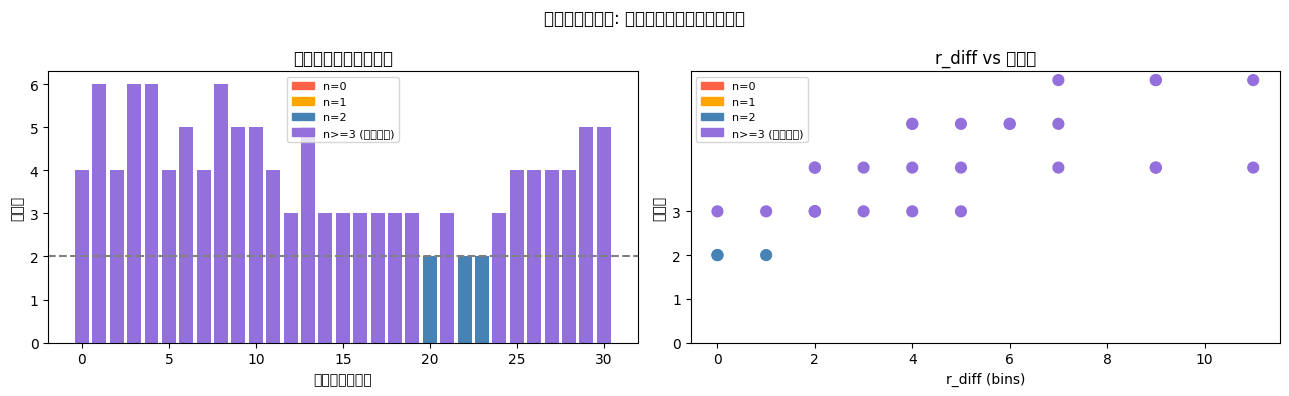

In [29]:
# === シナリオテストデータでの推論 (検出数ベース) ===
import torch, matplotlib.pyplot as plt

SCENARIO_META_CSV = "./learn_dataset_scenario_test/metadata.csv"
scenario_df = pd.read_csv(SCENARIO_META_CSV)
scenario_df = scenario_df[scenario_df["valid_all"] == 1].reset_index(drop=True)
print(f"シナリオテスト: {len(scenario_df)} サンプル")

rows_sc = []
for i in range(len(scenario_df)):
    row = scenario_df.iloc[i]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())
    # peaks: [(ch, d, r, conf), ...]

    cy_r = int(row["cyclist_true_r_idx"]); ve_r = int(row["vehicle_true_r_idx"])
    n = len(peaks)
    cy_min_dr = min(abs(p[2]-cy_r) for p in peaks) if peaks else 999
    ve_min_dr = min(abs(p[2]-ve_r) for p in peaks) if peaks else 999
    confs = [round(p[3], 3) for p in peaks]

    rows_sc.append({
        "step":      i,
        "cy_idx":    int(row["source_index_cyclist"]),
        "ve_idx":    int(row["source_index_vehicle"]),
        "r_diff":    abs(cy_r - ve_r),
        "n_peaks":   n,
        "cy_min_dr": cy_min_dr,
        "ve_min_dr": ve_min_dr,
        "confs":     confs,
    })

sc_df = pd.DataFrame(rows_sc)

print(f"{'step':>5}  {'cy_idx':>7}  {'ve_idx':>7}  {'r_diff':>6}  {'n_peaks':>7}  {'cy_dr':>6}  {'ve_dr':>6}  confs")
print("-" * 75)
for _, r in sc_df.iterrows():
    n_str = f"n={int(r['n_peaks'])}"
    fp_mark = " *FP*" if int(r["n_peaks"]) >= 3 else ""
    print(f"{int(r['step']):>5}  {int(r['cy_idx']):>7}  {int(r['ve_idx']):>7}  "
          f"{int(r['r_diff']):>6}  {n_str:>7}  {r['cy_min_dr']:>6.1f}  {r['ve_min_dr']:>6.1f}  "
          f"{r['confs']}{fp_mark}")

n0  = (sc_df["n_peaks"] == 0).sum()
n1  = (sc_df["n_peaks"] == 1).sum()
n2  = (sc_df["n_peaks"] == 2).sum()
n3p = (sc_df["n_peaks"] >= 3).sum()
total = len(sc_df)
print(f"=== 検出数集計 ===")
print(f"n=0  (全漏れ)  : {n0:>3}/{total} ({n0/total*100:.1f}%)")
print(f"n=1  (片方漏れ): {n1:>3}/{total} ({n1/total*100:.1f}%)")
print(f"n=2  (正常)    : {n2:>3}/{total} ({n2/total*100:.1f}%)")
print(f"n>=3 (誤検出含): {n3p:>3}/{total} ({n3p/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("シナリオテスト: 各タイムステップの検出数")

colors_map = {0: "tomato", 1: "orange", 2: "steelblue"}
bar_colors = ["mediumpurple" if n >= 3 else colors_map.get(n, "steelblue") for n in sc_df["n_peaks"]]
axes[0].bar(sc_df["step"], sc_df["n_peaks"], color=bar_colors)
axes[0].axhline(2, color="gray", linestyle="--", label="期待値 n=2")
axes[0].set_xlabel("タイムステップ"); axes[0].set_ylabel("検出数")
axes[0].set_title("ステップごとの検出数")
from matplotlib.patches import Patch
legend_els = [Patch(color=colors_map[k], label=f"n={k}") for k in [0,1,2]]
legend_els += [Patch(color="mediumpurple", label="n>=3 (誤検出含)")]
axes[0].legend(handles=legend_els, fontsize=8)

scatter_colors = ["mediumpurple" if n >= 3 else colors_map.get(n, "steelblue") for n in sc_df["n_peaks"]]
axes[1].scatter(sc_df["r_diff"], sc_df["n_peaks"], c=scatter_colors, s=60, zorder=3)
axes[1].set_xlabel("r_diff (bins)"); axes[1].set_ylabel("検出数")
axes[1].set_title("r_diff vs 検出数")
axes[1].set_yticks([0, 1, 2, 3])
axes[1].legend(handles=legend_els, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# === シナリオテスト: RDマップ確認 ===
import torch, matplotlib.pyplot as plt, numpy as np

VMIN, VMAX = -90, -10
TARGET_STEPS = list(range(10, 31))

scenario_df2 = pd.read_csv("./learn_dataset_scenario_test/metadata.csv")
scenario_df2 = scenario_df2[scenario_df2["valid_all"] == 1].reset_index(drop=True)

fig, axes = plt.subplots(len(TARGET_STEPS), 2, figsize=(13, 4 * len(TARGET_STEPS)))
fig.suptitle("シナリオテスト: RDマップ vs ヒートマップ", fontsize=13)

for row_i, step in enumerate(TARGET_STEPS):
    row = scenario_df2.iloc[step]
    npz_path = os.path.normpath(os.path.join(".", row["file"]))

    raw = np.load(npz_path)["rd_maps"]
    rd_db = 20.0 * np.log10(np.maximum(np.abs(raw[N_FIXED // 2]).astype(np.float32), 1e-12))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    heatmap = torch.sigmoid(logits)[0].max(dim=0).values.cpu().numpy()

    cy_r = int(row["cyclist_true_r_idx"]); cy_d = int(row["cyclist_true_d_idx"])
    ve_r = int(row["vehicle_true_r_idx"]); ve_d = int(row["vehicle_true_d_idx"])
    r_diff = abs(cy_r - ve_r)

    ax0, ax1 = axes[row_i]

    ax0.imshow(rd_db, aspect="auto", origin="lower", cmap="jet", vmin=VMIN, vmax=VMAX)
    ax0.set_title(f"step={step}  cy_idx={int(row['source_index_cyclist'])} ve_idx={int(row['source_index_vehicle'])}  r_diff={r_diff}")
    ax0.set_xlabel("range bin"); ax0.set_ylabel("doppler bin")

    ax1.imshow(heatmap, aspect="auto", origin="lower", cmap="magma")

plt.tight_layout()
plt.show()

sample 0
  cyclist : d=1, r=167, angle=2.85deg
  vehicle : d=1, r=124, angle=1.69deg


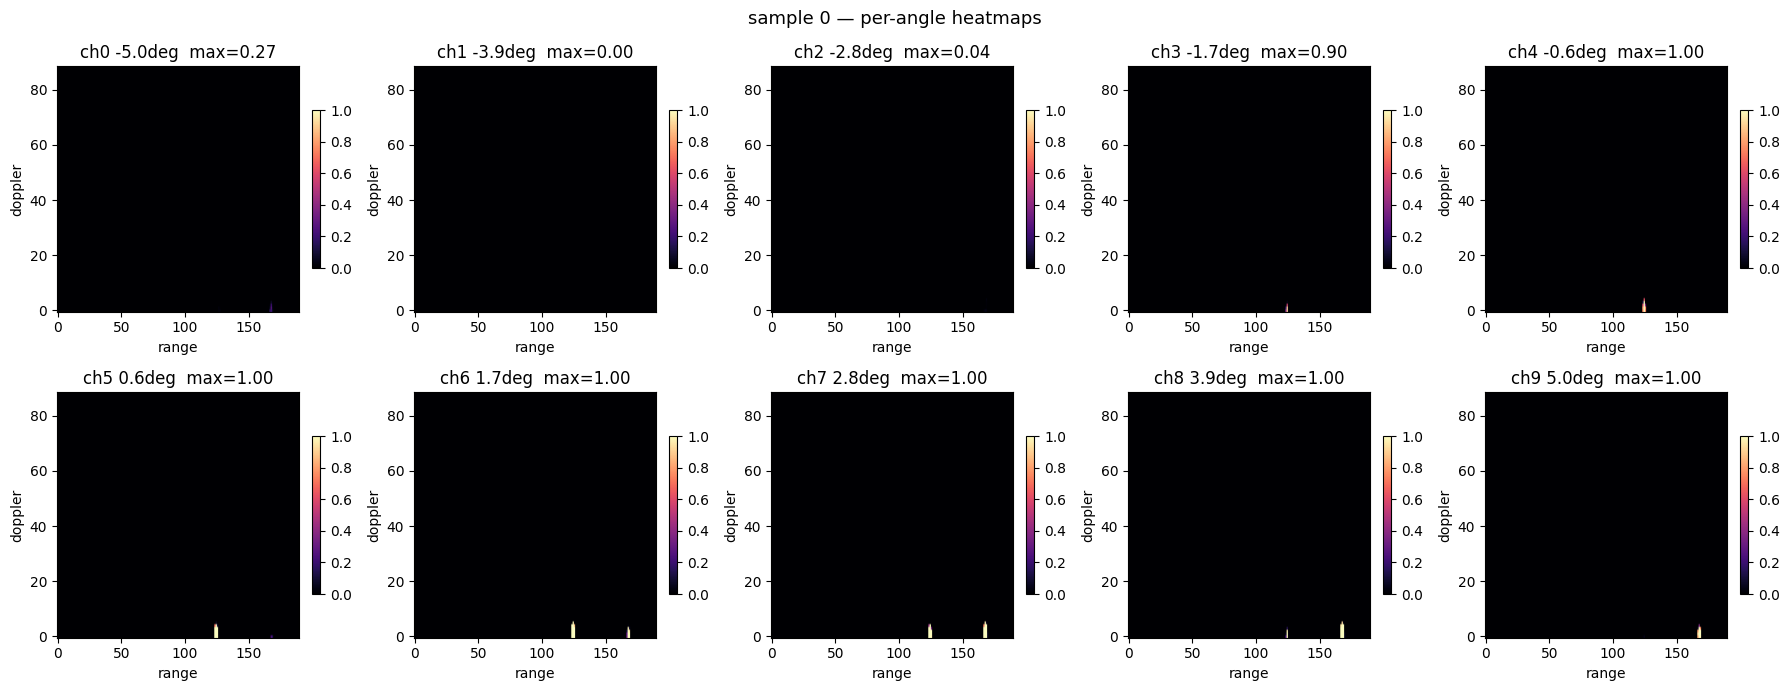

In [34]:
# === angle channel heatmaps ===
def show_angle_heatmaps(sample_idx=0, dataset_df=test_df):
    row = dataset_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    data = np.load(npz_path)
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    heatmaps = torch.sigmoid(logits)[0].cpu().numpy()  # (N_FIXED, H, W)

    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])
    cy_angle = float(data["cyclist_true_angle_deg"]) if "cyclist_true_angle_deg" in data else float("nan")
    ve_angle = float(data["vehicle_true_angle_deg"]) if "vehicle_true_angle_deg" in data else float("nan")

    print(f"sample {sample_idx}")
    print(f"  cyclist : d={cy_true_d}, r={cy_true_r}, angle={cy_angle:.2f}deg")
    print(f"  vehicle : d={ve_true_d}, r={ve_true_r}, angle={ve_angle:.2f}deg")

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle(f"sample {sample_idx} — per-angle heatmaps", fontsize=13)

    for i, ax in enumerate(axes.flat):
        im = ax.imshow(heatmaps[i], aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=1)
        ax.set_title(f"ch{i} {FIXED_ANGLES[i]:.1f}deg  max={heatmaps[i].max():.2f}")
        ax.set_xlabel("range")
        ax.set_ylabel("doppler")
        plt.colorbar(im, ax=ax, fraction=0.03)

    plt.tight_layout()
    plt.show()

show_angle_heatmaps(sample_idx=0)